In [1]:
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

datos = scipy.io.loadmat('S100629A011_IslArena_1.mat', squeeze_me=True, struct_as_record=False)
datosData = datos['Data']

In [19]:
t1 = datosData.Average_Time.T
t = pd.to_datetime(t1 - 719529, unit='D', origin='unix')
bat = datosData.Average_Battery.T
head = datosData.Average_Heading.T
pitch = datosData.Average_Pitch.T
roll = datosData.Average_Roll.T

temp = datosData.Average_Temperature.T
press = datosData.Average_Pressure.T

u = datosData.Average_VelEast
v = datosData.Average_VelNorth
w = datosData.Average_VelUp1

cor1 = datosData.Average_CorBeam1.T
cor2 = datosData.Average_CorBeam2.T
cor3 = datosData.Average_CorBeam3.T
cor4 = datosData.Average_CorBeam4.T

depth = np.arange(0.3,5.5,0.2)

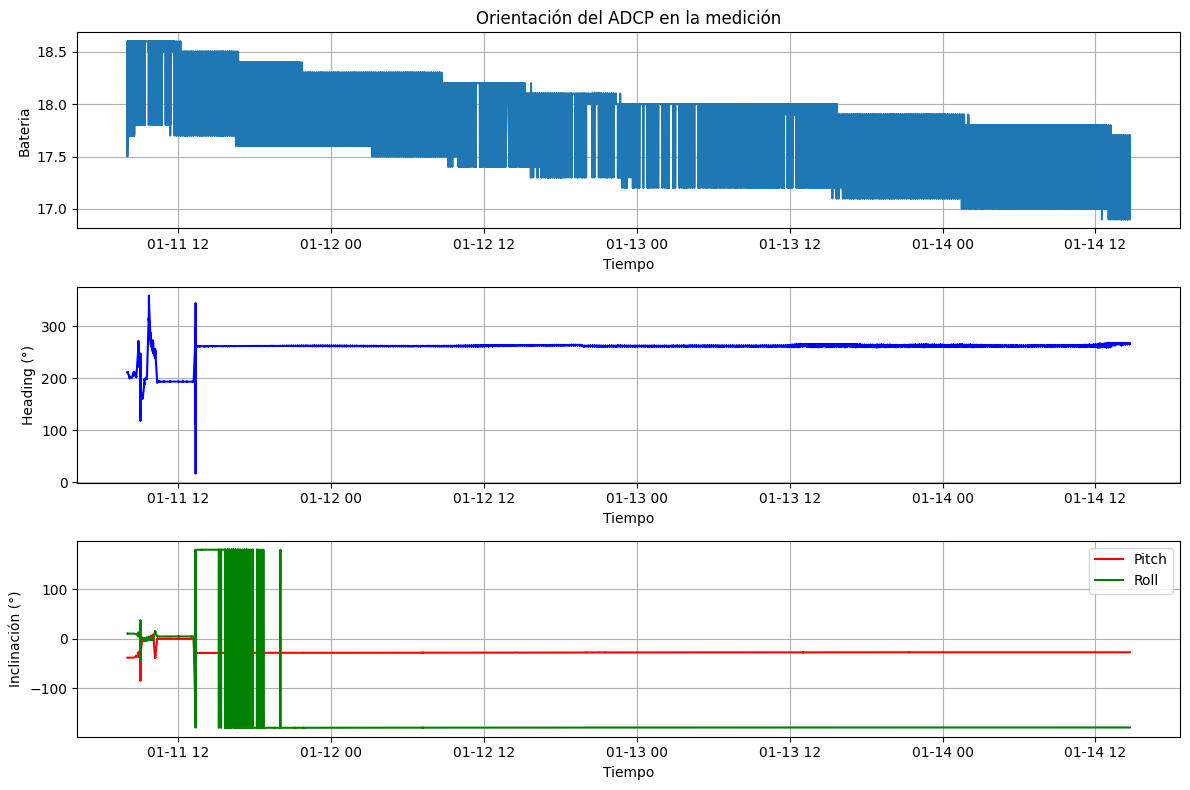

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Batería
axes[0].plot(t, bat)
axes[0].set_ylabel('Bateria')
axes[0].set_xlabel('Tiempo')
axes[0].set_title('Orientación del ADCP en la medición')
axes[0].grid(True)

# Heading
axes[1].plot(t, head, 'b')
axes[1].set_ylabel('Heading (°)')
axes[1].set_xlabel('Tiempo')
axes[1].grid(True)

# Pitch & Roll
axes[2].plot(t, pitch, 'r', label='Pitch')
axes[2].plot(t, roll, 'g', label='Roll')
axes[2].set_ylabel('Inclinación (°)')
axes[2].set_xlabel('Tiempo')
axes[2].legend(loc='best')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('adcp_orientation.png')
plt.show()

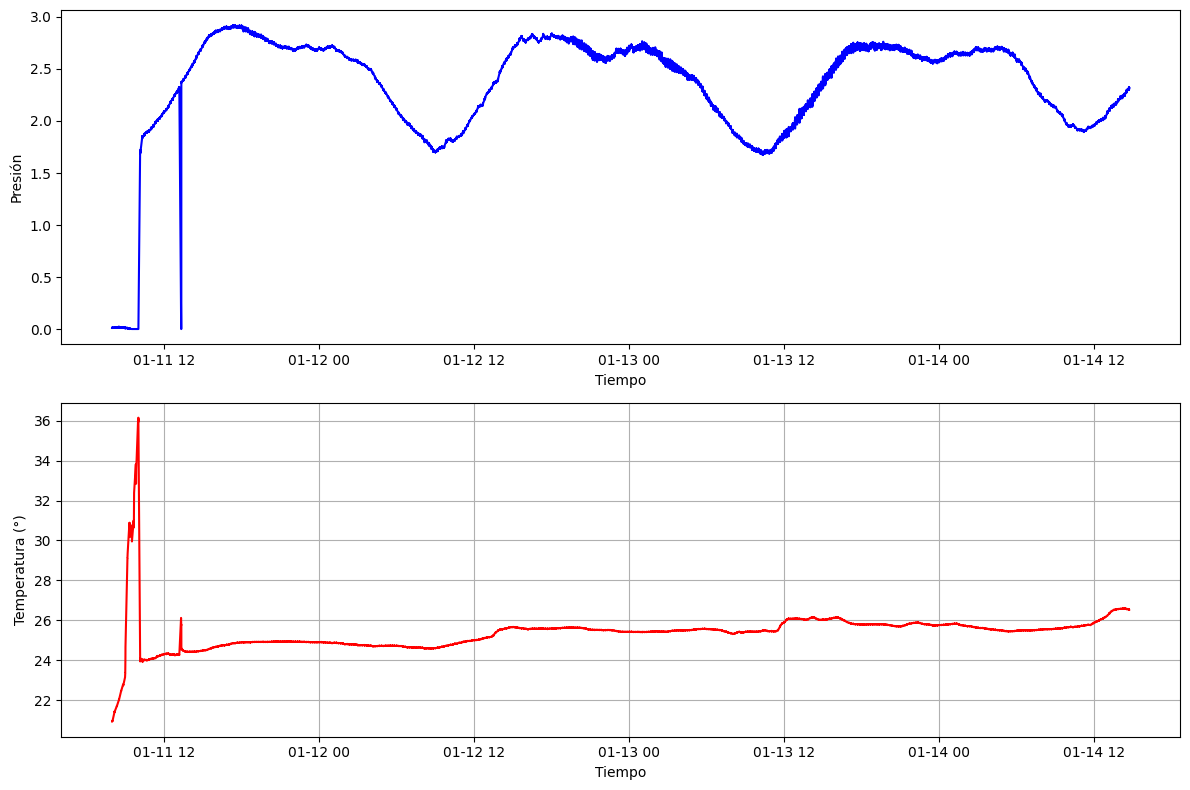

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Presión
axes[0].plot(t, press, 'b')
axes[0].set_ylabel('Presión')
axes[0].set_xlabel('Tiempo')

# Temperatura
axes[1].plot(t, temp, 'r')
axes[1].set_ylabel('Temperatura (°)')
axes[1].set_xlabel('Tiempo')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('adcp_temperatura_y_presion.png')
plt.show()


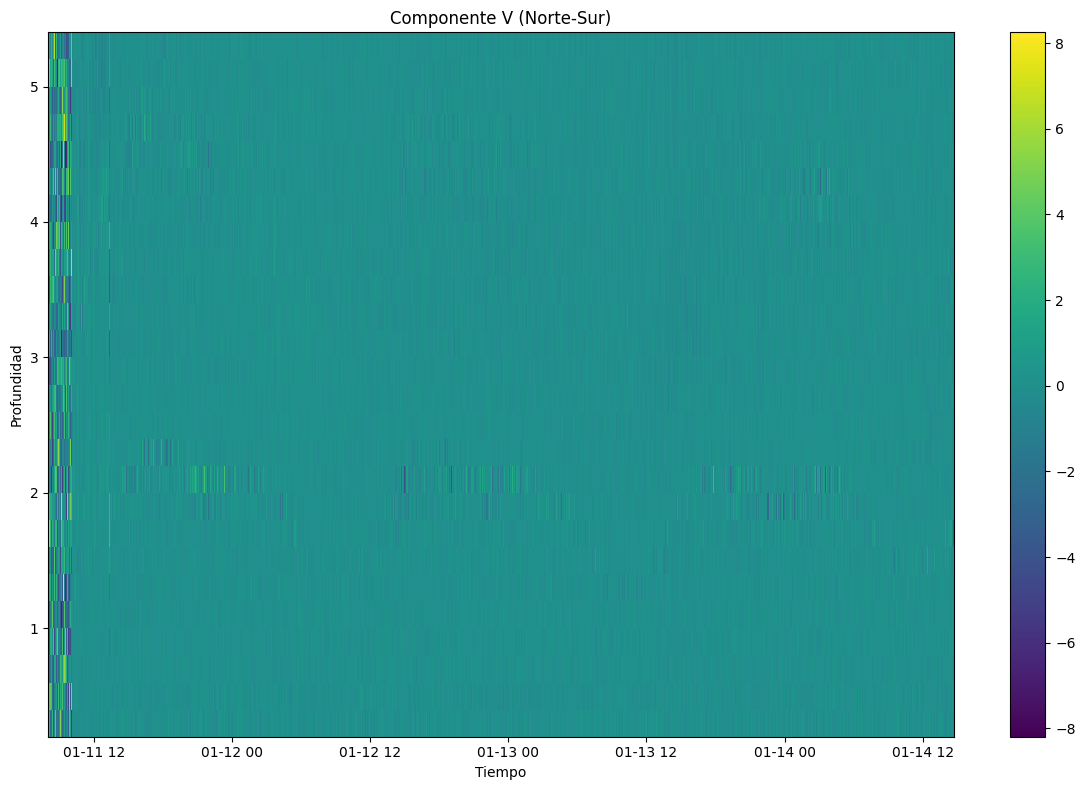

In [25]:
# Velocidad
fig, ax = plt.subplots(figsize=(12, 8))

c = ax.pcolormesh(t, depth, v.T, shading='nearest')
plt.colorbar(c, ax=ax)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Profundidad')
ax.set_title('Componente V (Norte-Sur)')

plt.tight_layout()
plt.savefig('Componente_v_norte-sur.png')
plt.show()


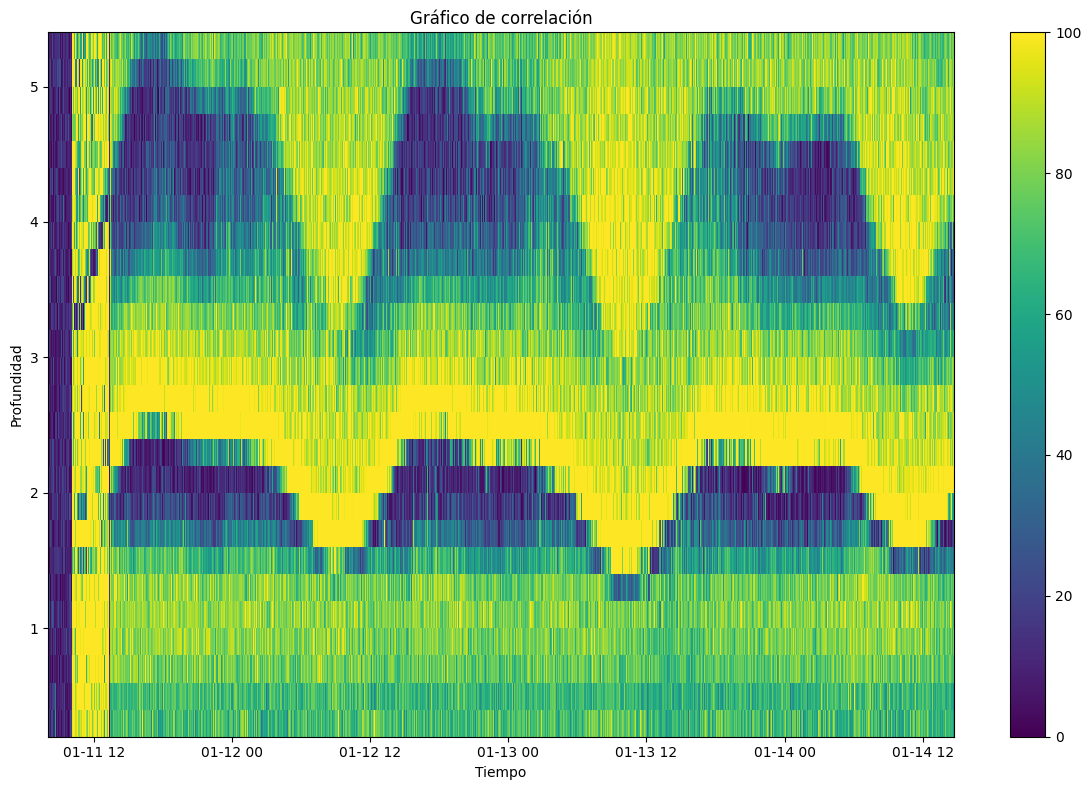

In [27]:
# Correlación
fig, ax = plt.subplots(figsize=(12, 8))

c = ax.pcolormesh(t, depth, cor1, shading='nearest')
plt.colorbar(c, ax=ax)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Profundidad')
ax.set_title('Gráfico de correlación')

plt.tight_layout()
plt.savefig('grafico_correlacion.png')
plt.show()

In [28]:
# Acotar en tiempo 
a = 1201
b = 56760

# Recorte temporal
t = t[a:b]
press = press[a:b]
temp = temp[a:b]
u = u[a:b,:]
v = v[a:b,:]
w = w[a:b,:]
cor1 = cor1[a:b]
cor2 = cor2[a:b]
cor3 = cor3[a:b]
cor4 = cor4[a:b]


In [29]:
# Rango de celdas

c = 1
d = 26
u = u[:, c:d]
v = v[:, c:d]
w = w[:, c:d]
depth = depth[c:d]

In [30]:
rows = 4
cols = len(t)/rows

t_Bu = np.reshape(t,[rows,cols]).T

TypeError: 'float' object cannot be interpreted as an integer